<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
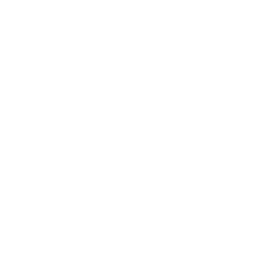
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">정준판별을 통한 고객 위험 프로파일링</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 금융 서비스 / 신용 위험 분석 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

소비자 모기지 포트폴리오의 세 가지 대출 상태 그룹 — **채무불이행(defaulted)**, **정상(current)**, **조기상환(prepaid)** — 은 여러 재무 건전성 차원에서 동시에 차이를 보이며, 이 때문에 어떤 단일 비율도 취약한 위험 신호가 됩니다. 이 노트북은 100명의 고객으로 구성된 위험 심사 표본에 **PROC CANDISC**(정준판별분석)를 적용하여, 상관관계가 있는 여섯 개의 재무 비율을 세 상태 그룹 간 분리를 최대화하는 두 개의 정준 차원으로 압축합니다.

첫 번째 정준 차원이 그룹 간 분리의 거의 전부를 담고 있으며 — 정준상관 **0.958**, 그 분산의 **91.8%** 를 그룹 소속과 공유 — 차용인을 한쪽 극단의 채무불이행에서 반대쪽 극단의 조기상환까지 깔끔하게 정렬합니다. 두 번째 차원(정준상관 **0.503**, 제곱 **0.254**)은 연체 이력과 레버리지가 주도하는 부차적 대비를 추가합니다. 제곱 마할라노비스 거리는 **DEFAULT** 와 **PREPAID** 중심점이 가장 멀리 떨어진 쌍(**75.3**)임을 확인시켜 주며, **CURRENT** 는 그 사이(DEFAULT에서 34.3, PREPAID에서 10.1)에 위치합니다. 그 결과 산출된 정준 점수는 포트폴리오 세분화와 스코어카드 보정에 적합한 간결한 복합 위험 지수를 형성합니다.

## 데이터 출처

| 출처 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | 대출 상태로 라벨링된 합성 고객 재무 비율 및 행동 지표로, 균형 잡힌 위험 심사 표본으로 추출됨 | 100 |

이 표본은 판별분석에서 각 상태 그룹이 안정적인 그룹 내 공분산 구조를 추정할 만큼 충분히 크도록, 채무불이행 및 조기상환 계정을 의도적으로 과대표집(사례-대조 방식의 추출)했습니다.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
데이터 work.loan_profiles;
    호출 streaminit(42);
    길이 loan_status $10 vintage $7 customer_id $12 status_ko $20;
    배열 statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    배열 vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    반복 i = 1 까지 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        만약 status_prob < 0.30 이면 status_idx = 1;       /* DEFAULT */
        아니면 만약 status_prob < 0.70 이면 status_idx = 2;  /* CURRENT */
        아니면 status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        만약 loan_status='DEFAULT' 이면 status_ko='부도';
        아니면 만약 loan_status='CURRENT' 이면 status_ko='정상';
        아니면 status_ko='조기상환';
        /* Financial ratios separate the three status groups */
        만약 loan_status = 'DEFAULT' 이면 반복;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        종료;
        아니면 만약 loan_status = 'CURRENT' 이면 반복;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        종료;
        아니면 반복;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        종료;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        만약 dti_ratio < 0.05 이면 dti_ratio = 0.05;
        만약 dti_ratio > 0.99 이면 dti_ratio = 0.99;
        만약 ltv_ratio < 0.10 이면 ltv_ratio = 0.10;
        만약 ltv_ratio > 1.20 이면 ltv_ratio = 1.20;
        만약 credit_utilization < 0.01 이면 credit_utilization = 0.01;
        만약 credit_utilization > 0.99 이면 credit_utilization = 0.99;
        출력;
    종료;
    제거 i status_prob status_idx;
    라벨 dti_ratio='부채 상환 비율(DTI)'
         ltv_ratio='담보 인정 비율(LTV)'
         payment_to_income='소득 대비 상환액'
         credit_utilization='신용 사용률'
         savings_balance='저축 잔액'
         months_delinquent='연체 개월수'
         loan_status='대출 상태'
         status_ko='대출 상태'
         vintage='빈티지(분기)';
실행;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  8.87 seconds
  cpu   8.87 seconds


---

### 기준 그룹 프로파일

비율을 압축하기에 앞서, 세 상태 그룹이 변수별로 어떻게 다른지 요약하고, 대출 개시 빈티지 전반에 걸친 표본 구성을 확인합니다.

                                                  The MEANS Procedure

                                Analysis Variable : dti_ratio 부채 상환 비율(DTI)

        대출 상태                  N Obs           Mean        Std Dev
        ----------------------------------------------------------
        부도                        29          0.570          0.114
        정상                        46          0.331          0.112
        조기상환                      25          0.216          0.056
        ----------------------------------------------------------

                                Analysis Variable : ltv_ratio 담보 인정 비율(LTV)

        대출 상태                  N Obs           Mean        Std Dev
        ----------------------------------------------------------
        부도                        29          0.914          0.103
        정상                        46          0.776          0.080
        조기상환                      25          0.585          0.104
        -----------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_status_ko.spec.json
NOTE: PROC FREQ statement used.


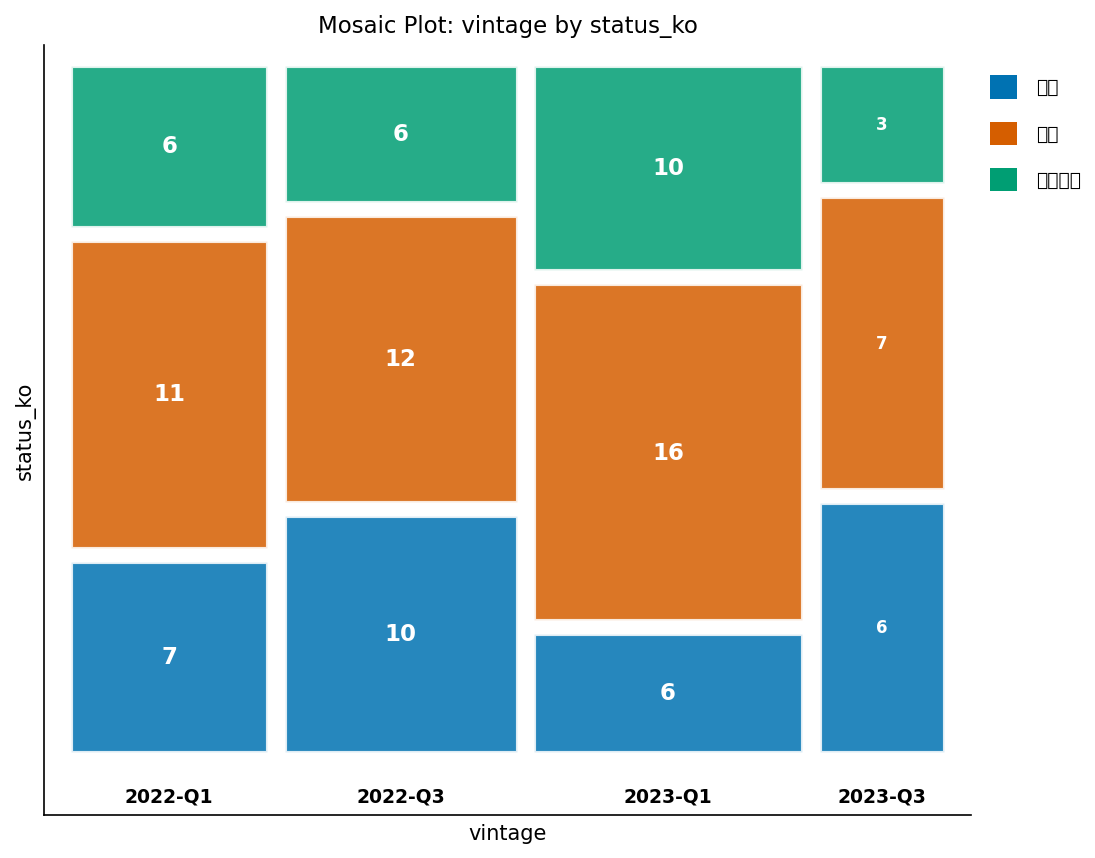

In [2]:
/* --------------------------------------------------------
   Baseline financial-ratio distributions by loan status
   -------------------------------------------------------- */
처리 평균 데이터=work.loan_profiles n mean std maxdec=3;
    분류 status_ko;
    변수 dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
실행;

/* --------------------------------------------------------
   Sample composition by vintage and status
   -------------------------------------------------------- */
처리 빈도 데이터=work.loan_profiles;
    TABLES vintage * status_ko / nocum nopercent;
실행;

---

### 정준판별분석

100명의 고객 전체에 대해 하나의 통합 정준판별 모델을 적합합니다. `OUT=` 은 고객별 정준 점수를 기록하고, `OUTSTAT=` 은 정준 구조, 클래스 중심점, 제곱 마할라노비스 거리를 담으며, `DISTANCE` 는 그룹 간 거리를 요청합니다. 여기서 명시된 프로시저는 실제로 실행되는 것과 정확히 동일합니다: **PROC CANDISC**.


NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   부도: 29
NOTE:   정상: 46
NOTE:   조기상환: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley     11.538269 

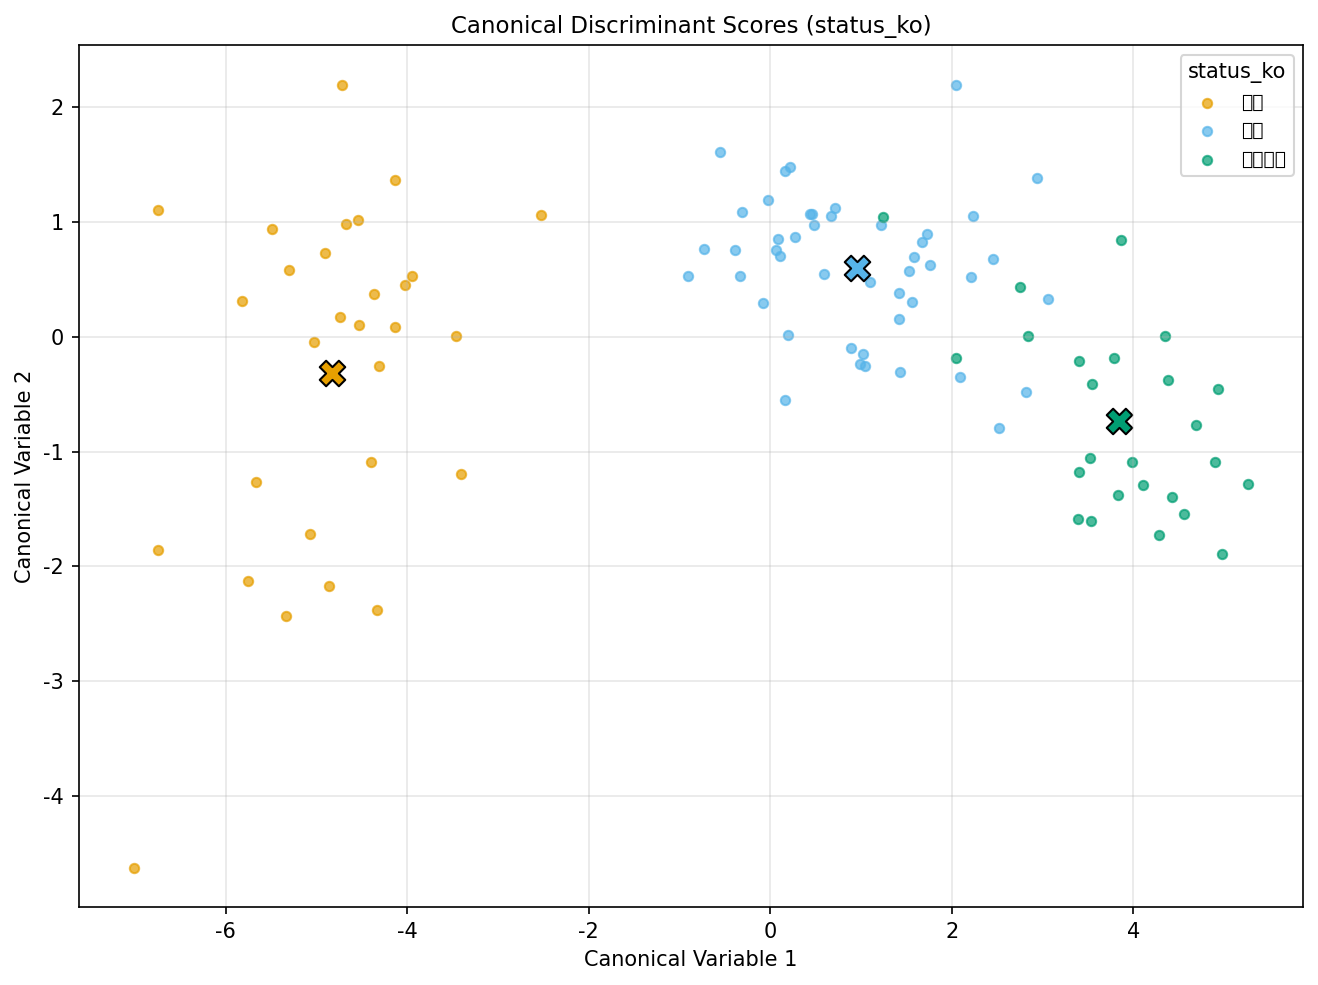

In [3]:
/* --------------------------------------------------------
   Canonical discriminant analysis of loan-status groups.
   OUT=    per-customer canonical scores (Can1, Can2)
   OUTSTAT= structure, class means, Mahalanobis distances
   -------------------------------------------------------- */
ODS 출력 CanonicalCorrelations=work.can_corr;

처리 CANDISC 데이터=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    분류 status_ko;
    변수 dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    제목 '대출 상태 그룹의 정준판별 위험 분석';
실행;

ODS 출력 CLOSE;

---

### 정준상관

각 정준 차원이 세 그룹 간 분리를 얼마나 포착하는지를 나타냅니다.

In [4]:
처리 인쇄 데이터=work.can_corr noobs;
    제목 '정준 상관';
실행;

                                                         정준 상관                                                          

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### 정준 구조 (변수 적재값)

각 원래 재무 비율과 두 정준 차원 간의 상관관계 — 이것이 차원을 해석하는 방식입니다.

In [5]:
처리 인쇄 데이터=work.can_stat noobs;
    조건 _type_ = 'STRUCTUR';
    변수 _name_ Can1 Can2;
    제목 '통합 급내 정준 구조';
실행;

                                                      통합 급내 정준 구조                                                       

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### 그룹 중심점과 마할라노비스 거리

정준 축 상의 클래스 평균(그룹 중심점)과 각 그룹 쌍 사이의 제곱 마할라노비스 거리 — 위험 점수 보정의 기초입니다.

In [6]:
처리 인쇄 데이터=work.can_stat noobs;
    조건 _type_ IN ('CANMEAN' 'DIST');
    변수 _type_ _name_ Can1 Can2;
    제목 '그룹 중심(CANMEAN) 및 제곱 마할라노비스 거리(DIST)';
실행;

                                          그룹 중심(CANMEAN) 및 제곱 마할라노비스 거리(DIST)                                           

 _TYPE_                  _NAME_       CAN1       CAN2
CANMEAN  부도                      -4.826727  -0.316237
CANMEAN  정상                       0.956102    0.59917
CANMEAN  조기상환                     3.839776  -0.735639
DIST     부도 to 정상                34.279058          .
DIST     부도 to 조기상환              75.284092          .
DIST     정상 to 조기상환              10.097273          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### 정준판별 지도

각 고객을 2차원 정준 공간에 대출 상태별로 색을 달리하여 표시합니다. 잘 분리된 군집은 정준 점수가 강한 그룹 정보를 담고 있음을 나타냅니다.

                                          그룹 중심(CANMEAN) 및 제곱 마할라노비스 거리(DIST)                                           




NOTE: DATA work.risk_scores_disp


NOTE: Read 100 rows from work.risk_scores.
NOTE: Wrote work.risk_scores_disp (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=work.risk_scores_disp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


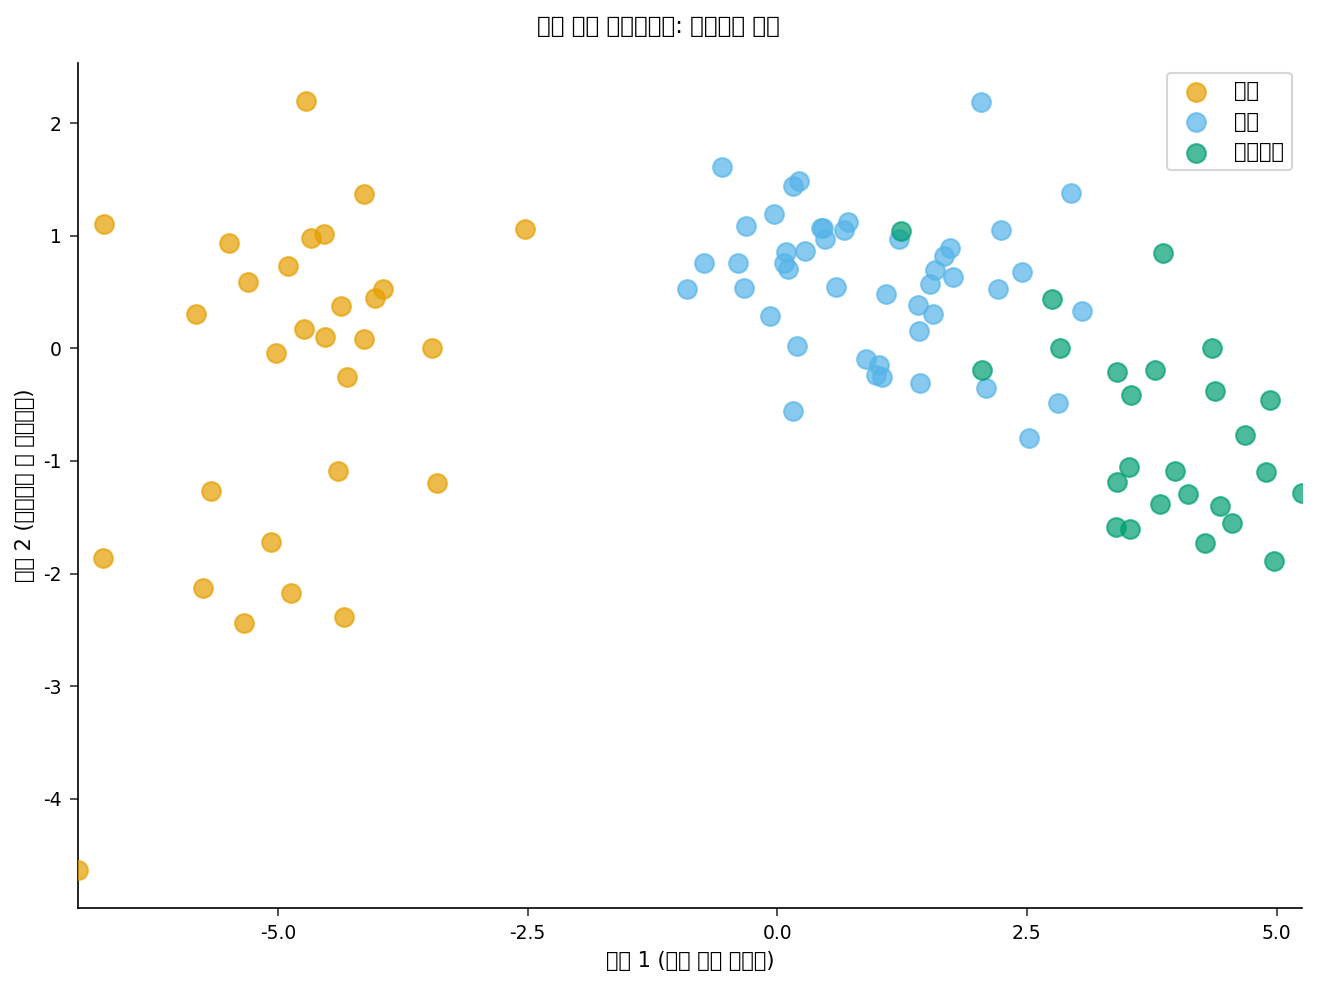

In [7]:
데이터 work.risk_scores_disp;
    설정 work.risk_scores;
    길이 status_ko $20;
    만약 loan_status='DEFAULT' 이면 status_ko='부도';
    아니면 만약 loan_status='CURRENT' 이면 status_ko='정상';
    아니면 status_ko='조기상환';
    라벨 status_ko='대출 상태';
실행;

처리 SGPLOT 데이터=work.risk_scores_disp;
    SCATTER x=Can1 y=Can2 / GROUP=status_ko
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS 라벨='정준 1 (부도 위험 심각도)';
    YAXIS 라벨='정준 2 (조기상환 대 레버리지)';
    제목 '고객 위험 프로파일링: 정준판별 공간';
실행;

---

### 해석

두 정준 차원은 이 100명 고객 표본(정상 46명, 채무불이행 29명, 조기상환 25명) 내에서 세 대출 상태 그룹을 뚜렷하게 분리합니다.

**차원 1 — 채무불이행 위험 심각도 (정준상관 0.958, 공유분산 91.8%).** 이 축 하나만으로 그룹 분리의 절대다수를 설명합니다(고유값 11.20 대 두 번째 축의 0.34). 통합 그룹 내 정준 구조에서 이 축은 신용 사용률(-0.595), 부채 대비 소득(-0.404), LTV(-0.370), 연체 개월수(-0.324), 상환액 대비 소득(-0.304)에 가장 강하게 적재되며 — 모든 레버리지 및 부담 지표가 같은 방향을 가리킵니다. 적재값이 음수이므로 낮은(더 음수인) Can1 점수가 가장 위험이 높은 차용인을 표시합니다. 클래스 중심점이 이를 뒷받침합니다: 채무불이행 계정은 Can1 = -4.83, 정상 계정은 +0.96, 조기상환 계정은 +3.84 에 위치하여, 신용 건전성이 최악에서 최상으로 깔끔한 단조 순서를 이룹니다.

**차원 2 — 레버리지 대 연체 (정준상관 0.503).** 두 번째 축은 LTV 비율(+0.733)과 연체 개월수(-0.700)를 대비시킵니다: 즉 레버리지가 높지만 정상인 차용인과 연체를 안고 있는 차용인을 분리합니다. 이는 Can1 내부의 그림을 정교화하지만 분리에는 훨씬 적게 기여하는데, 성과가 양호한 두 그룹의 거의 대등한 Can2 중심점(정상 +0.599, 조기상환 -0.736)이 이를 보여줍니다.

**그룹 분리.** 클래스 평균 간 제곱 마할라노비스 거리가 그 간격을 정량화합니다: DEFAULT-PREPAID 가 75.3 으로 가장 크고, DEFAULT-CURRENT 는 34.3, CURRENT-PREPAID 는 10.1 로 가장 작습니다. 따라서 성과가 양호한 두 그룹은 각자 채무불이행 그룹과 떨어진 거리보다 서로 간에 더 가까우며, 이는 대출기관이 기대하는 바와 정확히 일치합니다.

**실무적 활용.** 첫 번째 정준 점수는 곧바로 사용할 수 있는 복합 위험 지수처럼 작동합니다: 상관관계가 있는 여섯 개의 비율을 잘 분리된 하나의 차원으로 압축하여 고객을 채무불이행 위험이 가장 높은 순부터 가장 낮은 순으로 정렬합니다. 포트폴리오 팀은 Can1 절단점을 기준으로 세분화할 수 있고, 마할라노비스 거리는 스코어카드 보정 시 신규 신청자를 가장 가까운 상태 그룹에 배정하는 원칙적 근거를 제공합니다.

---

### 스코어링 엔진용 내보내기

고객별 정준 점수와 (중심점 및 마할라노비스 거리를 담고 있는) 정준 통계 데이터셋을 후속 스코어카드 보정을 위해 저장합니다.

In [8]:
/* --------------------------------------------------------
   Export canonical risk scores and canonical statistics
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 대외비
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>